# 01 - Exploratory Data Analysis (EDA)

## 1. Project Objective
The aim of this study is to analyze and visualize the features used in breast cancer diagnosis using the **Breast Cancer Wisconsin (Diagnostic)** dataset. These features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass and describe characteristics of the cell nuclei present in the image.

## 2. About the Dataset
The dataset typically contains **30 numeric features** for each patient. These features are grouped into three main categories based on how they were computed:
* **Mean:** The average value of the feature for all nuclei in the image.
* **SE (Standard Error):** The variation (standard error) of the feature.
* **Worst:** The mean of the three largest values (representing the most abnormal nuclei).

## 3. Analysis Steps
The following steps will be performed in this notebook:
1.  **Data Cleaning:** Dropping unnecessary columns (ID, empty columns like 'Unnamed: 32').
2.  **Distribution Analysis (Histograms & Boxplots):** Examining the distribution of features for malignant vs. benign cases.
3.  **Correlation Analysis:** Detecting relationships between features (Checking for Multicollinearity).
4.  **PCA (Principal Component Analysis):** Reducing the high-dimensional data to 2 dimensions to visualize and test separability.


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set the exact style from your original file
plt.style.use('fivethirtyeight')
%matplotlib inline

In [91]:
import pandas as pd
import os
from IPython.display import display 


pd.set_option('display.max_columns', None)

# 1. Print current location (Important for debugging)
print("Current working directory:", os.getcwd())

# 2. List of possible paths where the file might be located
possible_paths = [
    "../data/data.csv",       # Most likely location (data folder one level up)
    "../data/raw/data.csv",   # If inside a raw folder
    "data/data.csv",          # If running from root
    "data.csv"                # If file is in the same folder as the notebook
]

file_path = None

# 3. Search for the file
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        print(f" File found at: {path}")
        break

# 4. Load and Process
if file_path:
    data = pd.read_csv(file_path)
    
   

Current working directory: c:\Users\sidar\Quantum_SVM_for_Breast_Cancer_Diagnosis\notebooks
 File found at: ../data/raw/data.csv


In [92]:
# Drop useless columns
cols_to_drop = ['id', 'Unnamed: 32']
for col in cols_to_drop:
    if col in data.columns:
        data.drop(col, axis=1, inplace=True)

# Encode Diagnosis: M -> 1, B -> 0
if data['diagnosis'].dtype == 'object':
    data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

print("Data cleaned and encoded.")
data.head()

Data cleaned and encoded.


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [93]:
# Statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


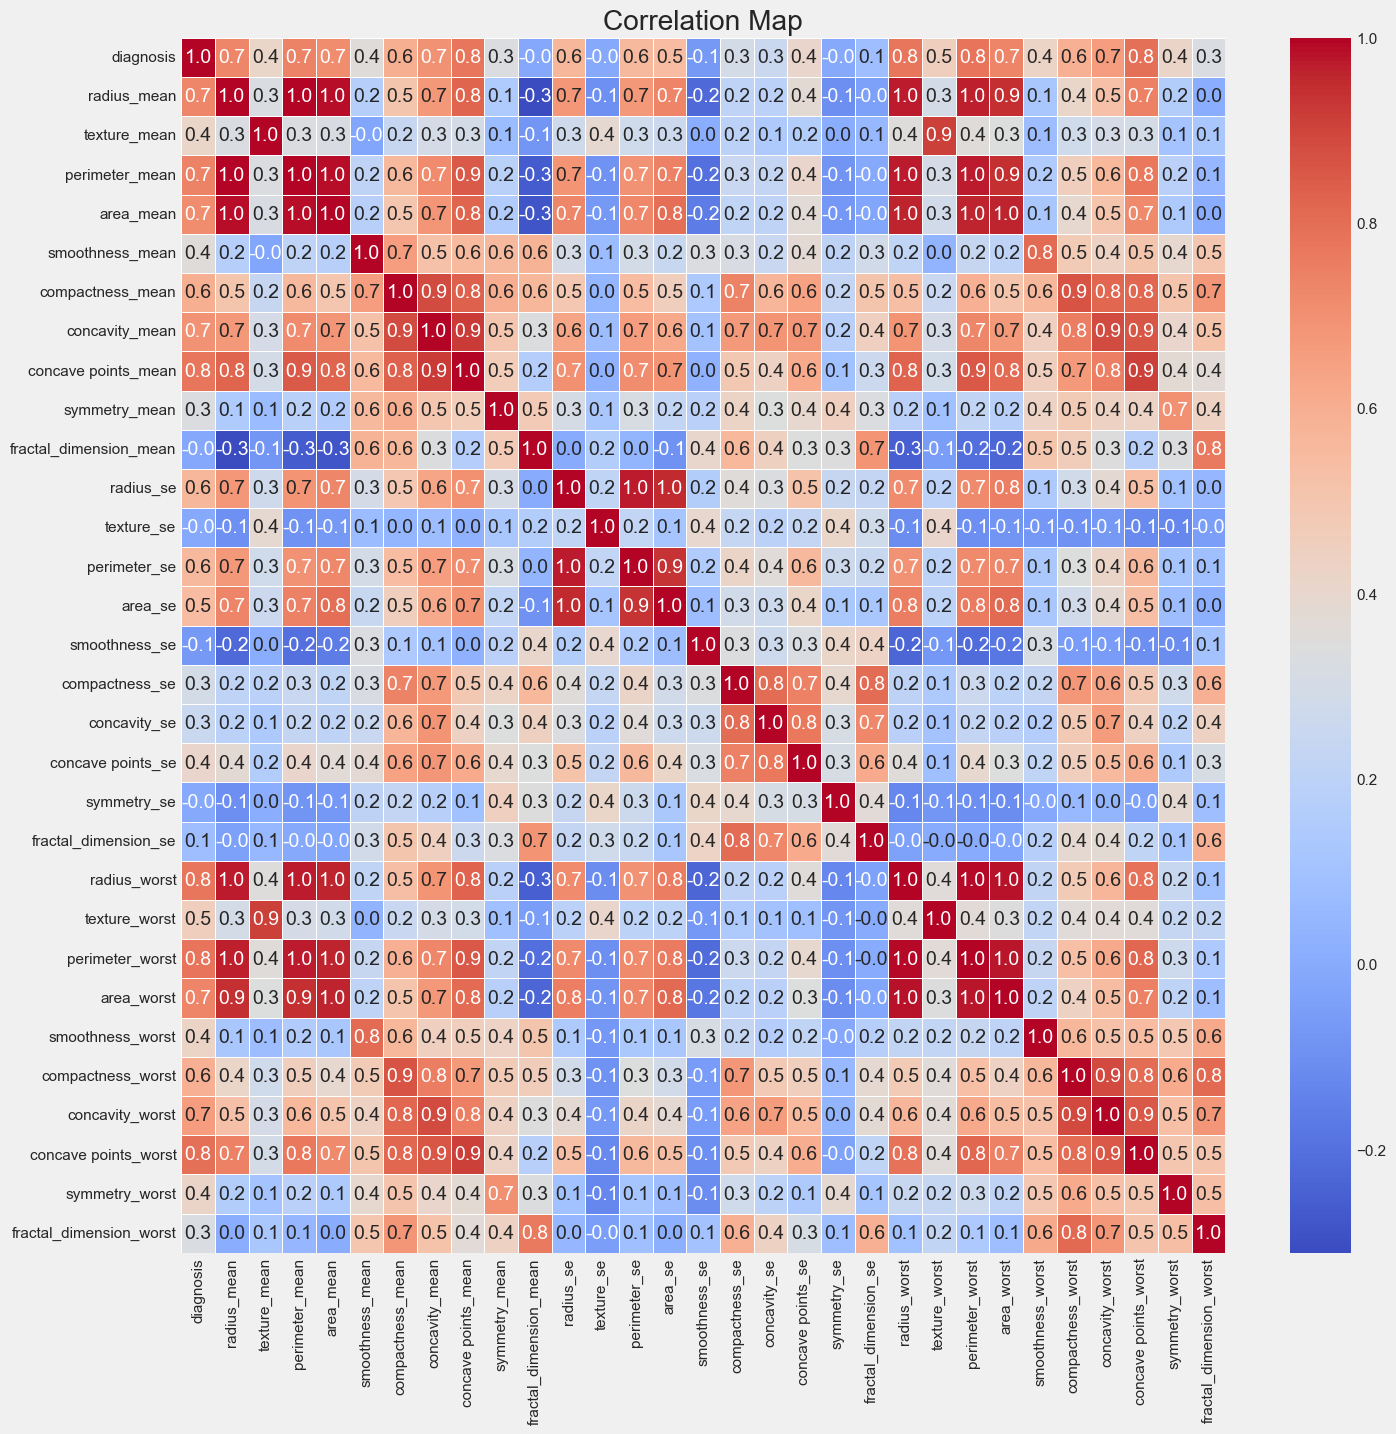

In [94]:
plt.figure(figsize=(15, 15))
# Creates the correlation matrix heatmap
sns.heatmap(data.corr(), annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Map')
plt.show()

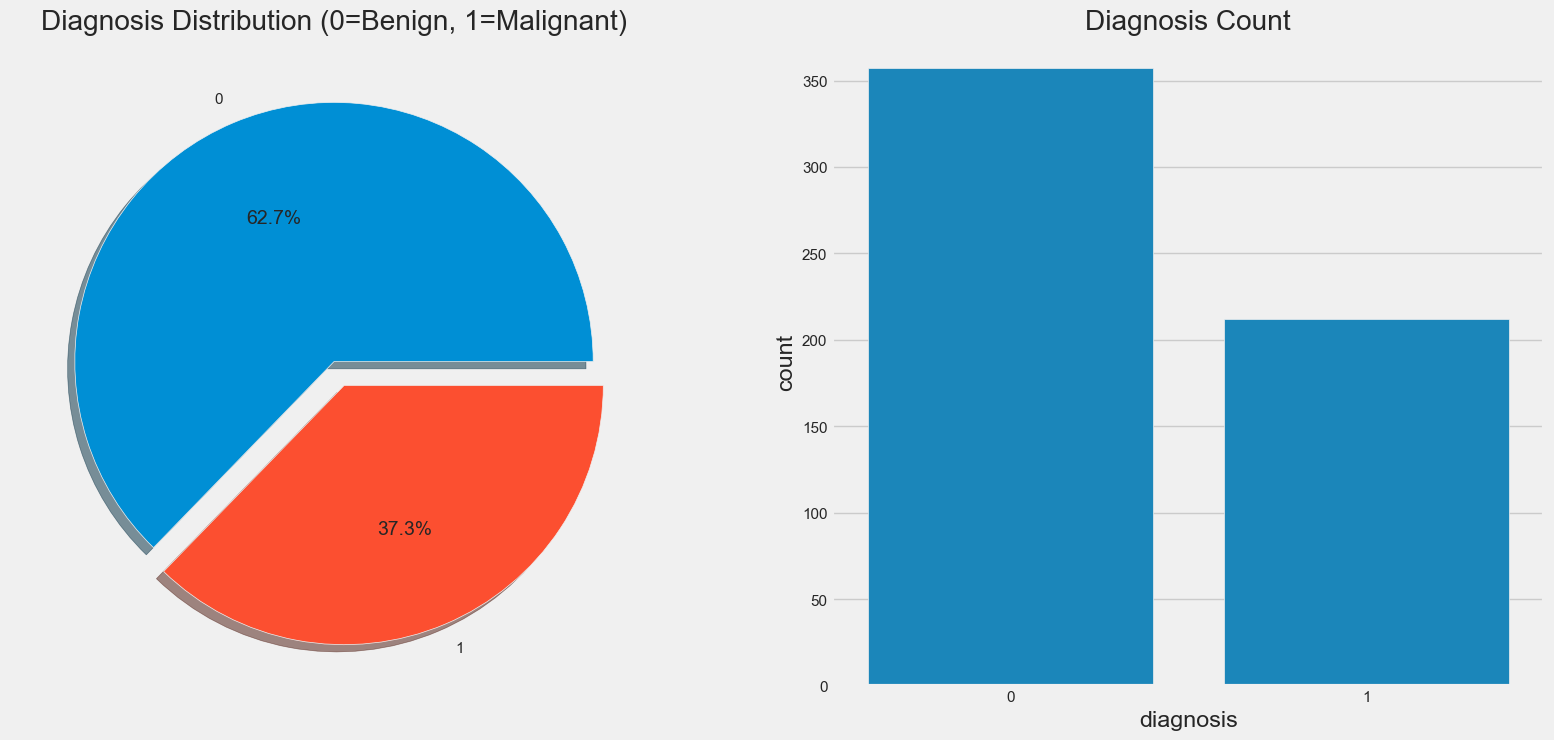

In [95]:
# Create a figure with 2 subplots side-by-side
f, ax = plt.subplots(1, 2, figsize=(18, 8))

# 1. Plot: Pie Chart (Distribution)
data['diagnosis'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_title('Diagnosis Distribution (0=Benign, 1=Malignant)')
ax[0].set_ylabel('') # Removes the label on the side for a cleaner look

# 2. Plot: Count Plot (Bar Chart)
sns.countplot(x='diagnosis', data=data, ax=ax[1])
ax[1].set_title('Diagnosis Count')

# Show the plot
plt.show()

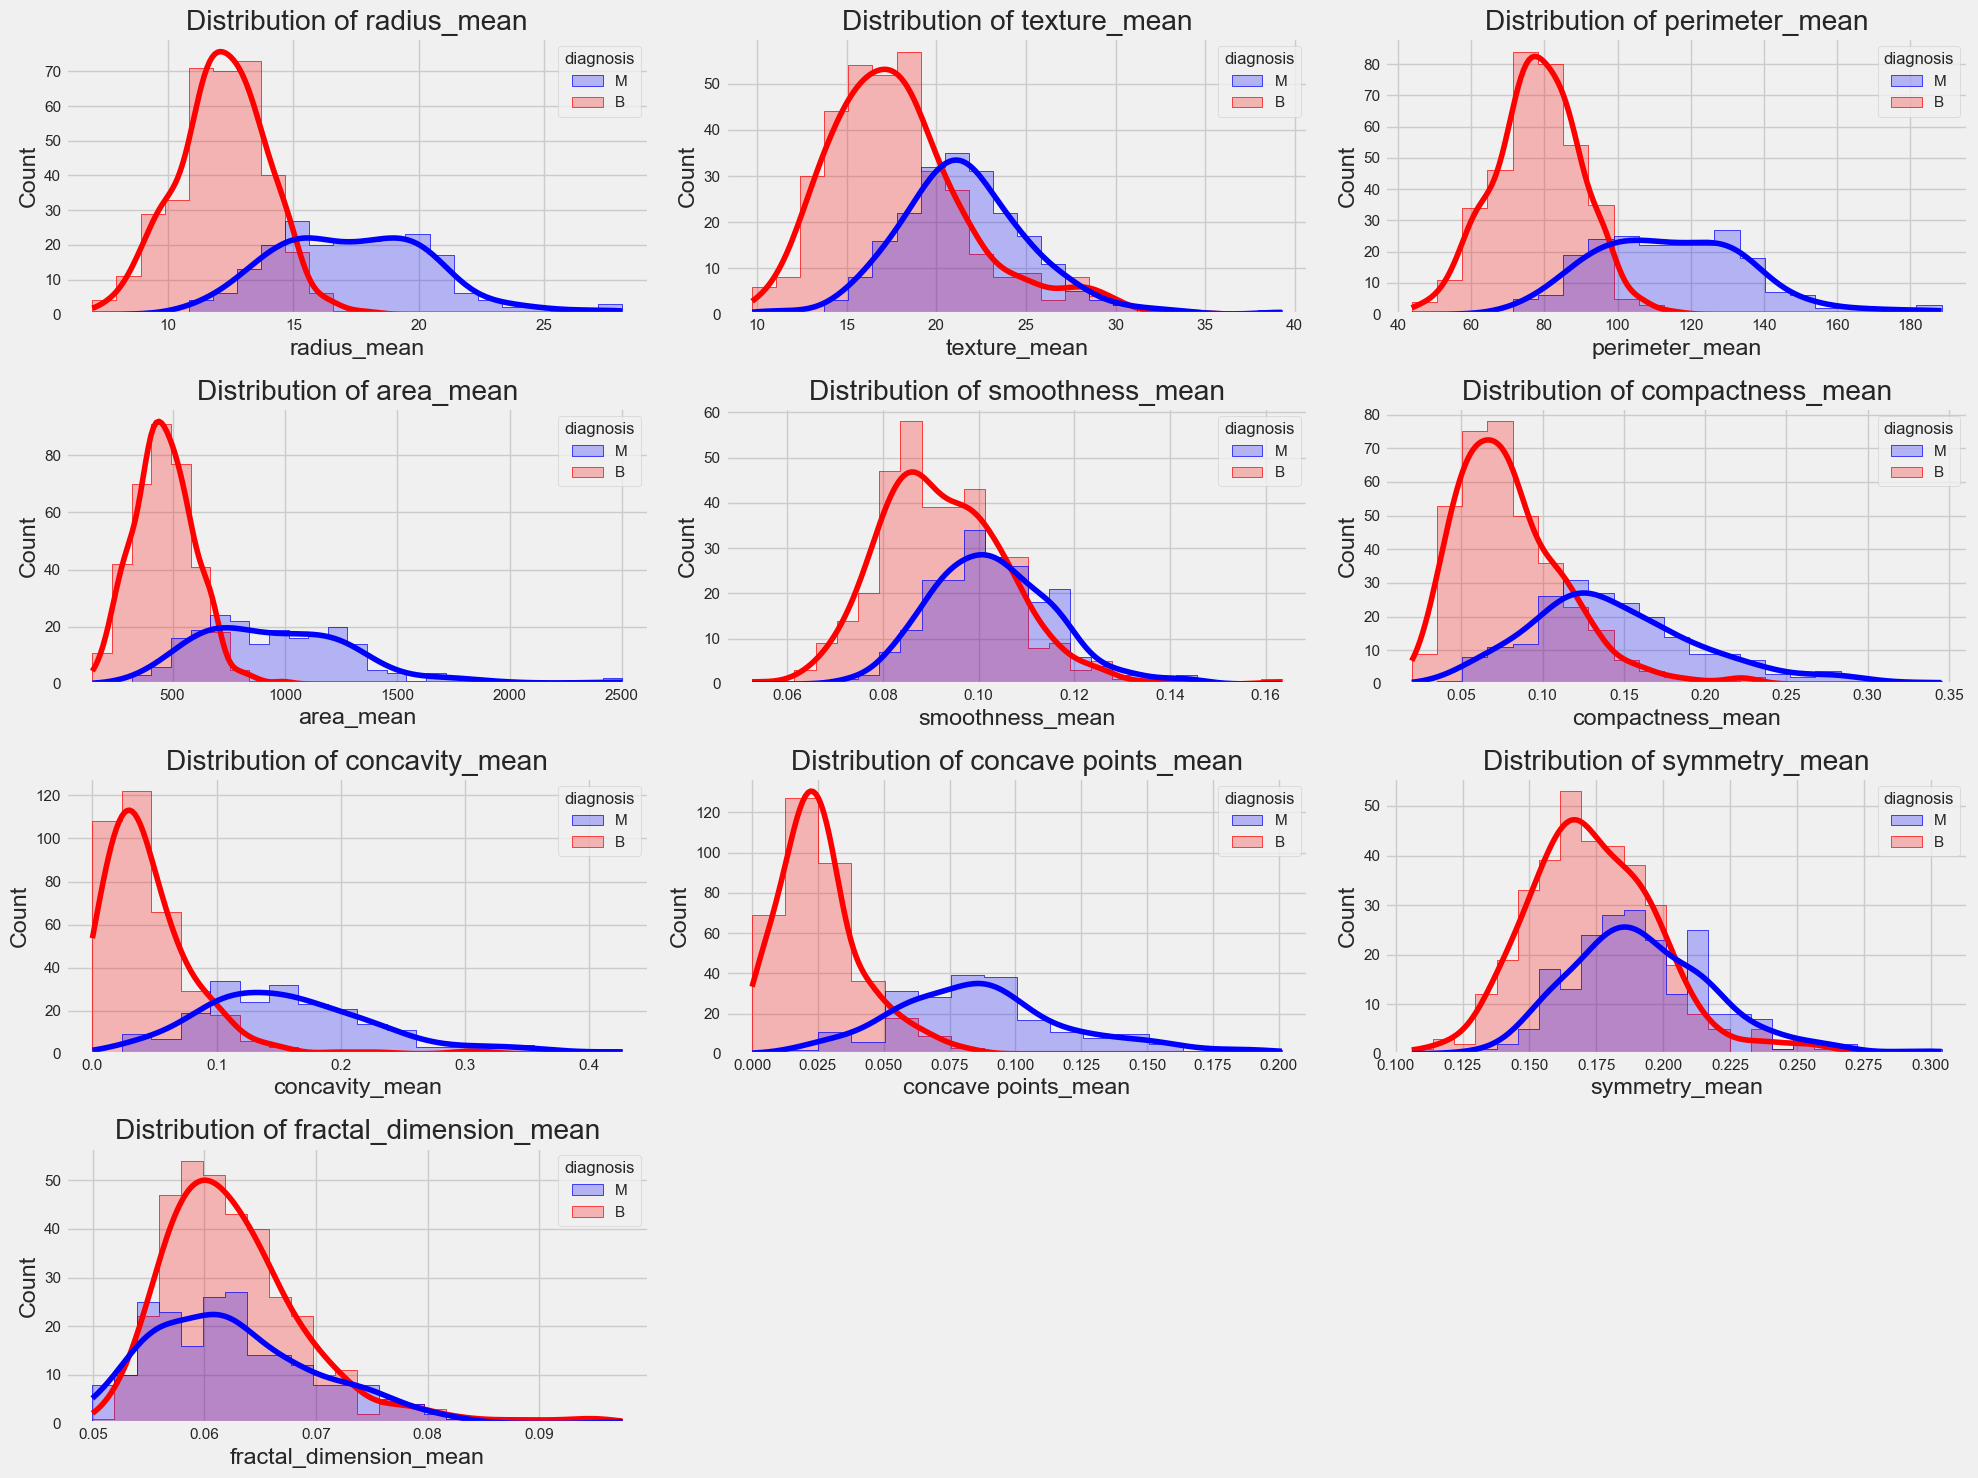

In [96]:
# Features to visualize (Only 'mean' features for clarity)
features_mean = ['radius_mean', 'texture_mean', 'perimeter_mean',
                 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
                 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

plt.figure(figsize=(20, 15))

for i, feature in enumerate(features_mean):
    plt.subplot(4, 3, i+1) # 4 rows, 3 columns layout
    
    # Plot classes 0 and 1 separately
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, element="step", palette=['blue', 'red'])
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

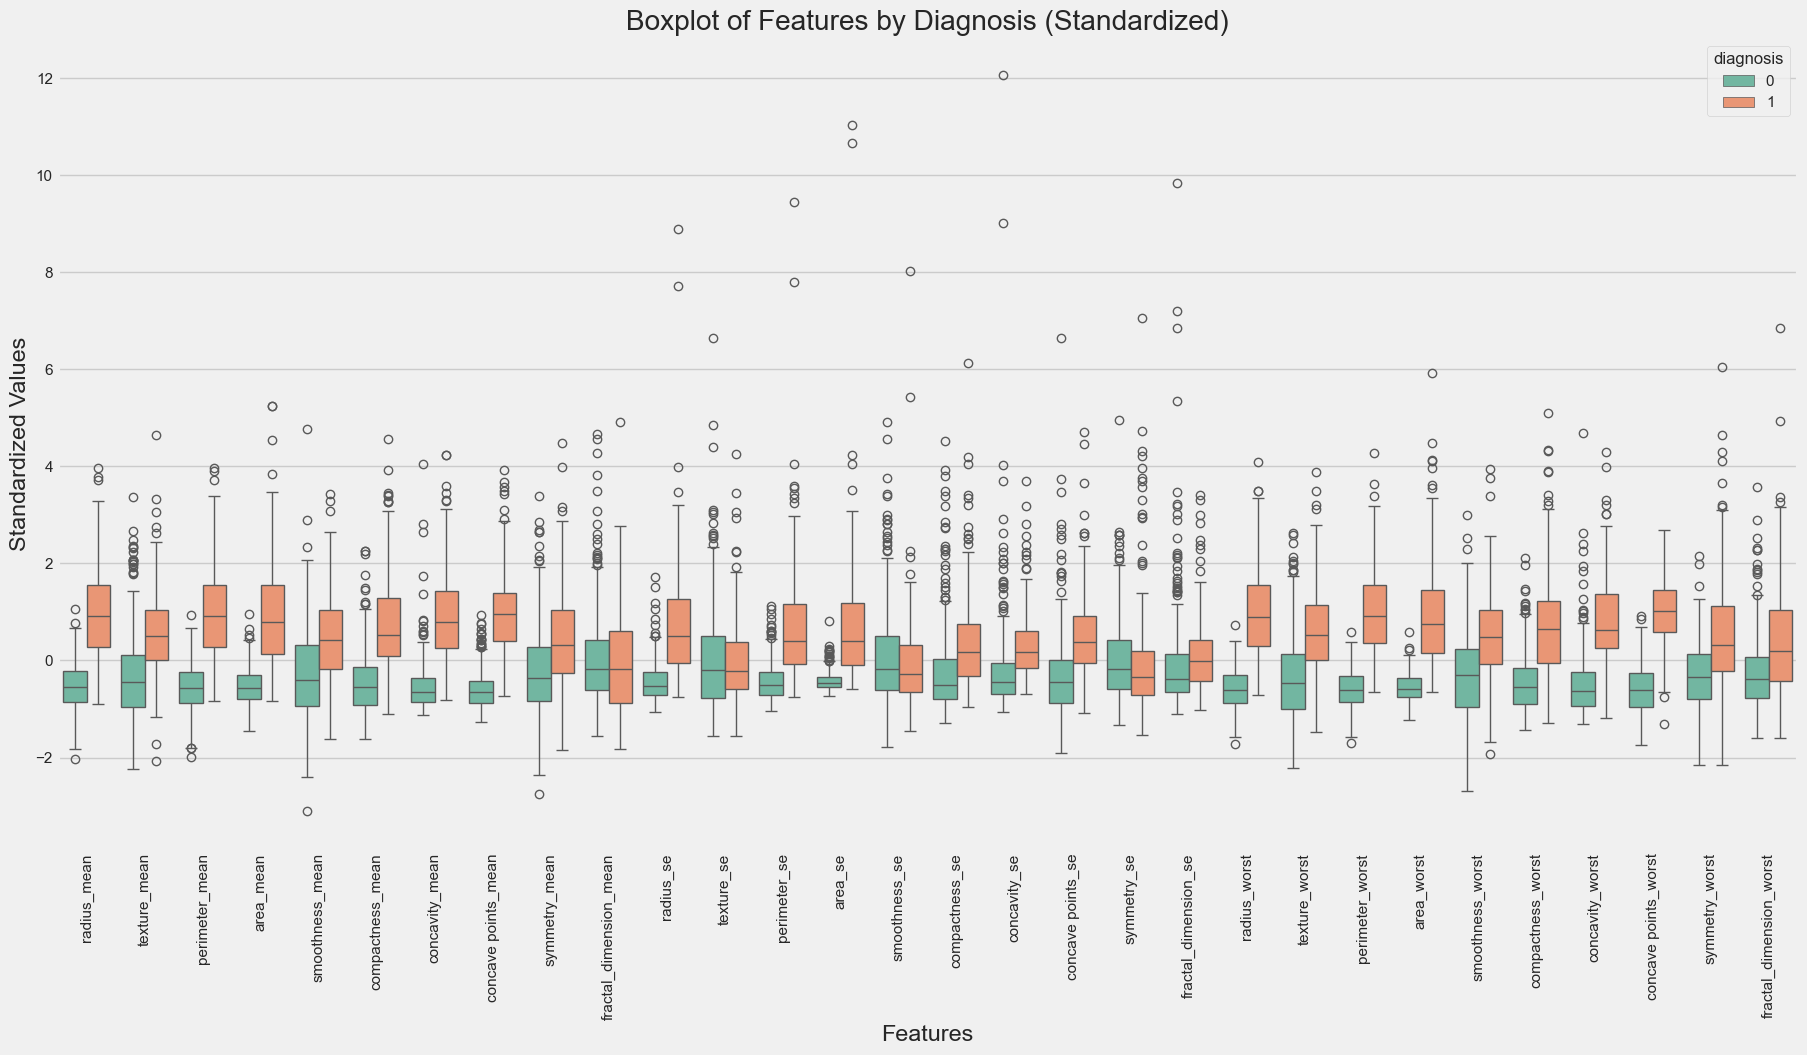

In [97]:
# Standardize data for better boxplot visualization
# (Since 'area' values are ~1000 and 'smoothness' is ~0.1, we need to scale them to see them together)
data_n_2 = (data - data.mean()) / (data.std()) # Standardization
data = pd.concat([data['diagnosis'], data_n_2.iloc[:, 1:]], axis=1) # Re-attach diagnosis

# Melt the data for Seaborn plotting
data_melted = pd.melt(data, id_vars="diagnosis",
                      var_name="features",
                      value_name='value')

plt.figure(figsize=(20, 10))
# Create the boxplot
sns.boxplot(x="features", y="value", hue="diagnosis", data=data_melted, palette="Set2")
plt.xticks(rotation=90) # Rotate labels to fit
plt.title("Boxplot of Features by Diagnosis (Standardized)")
plt.xlabel("Features")
plt.ylabel("Standardized Values")
plt.show()

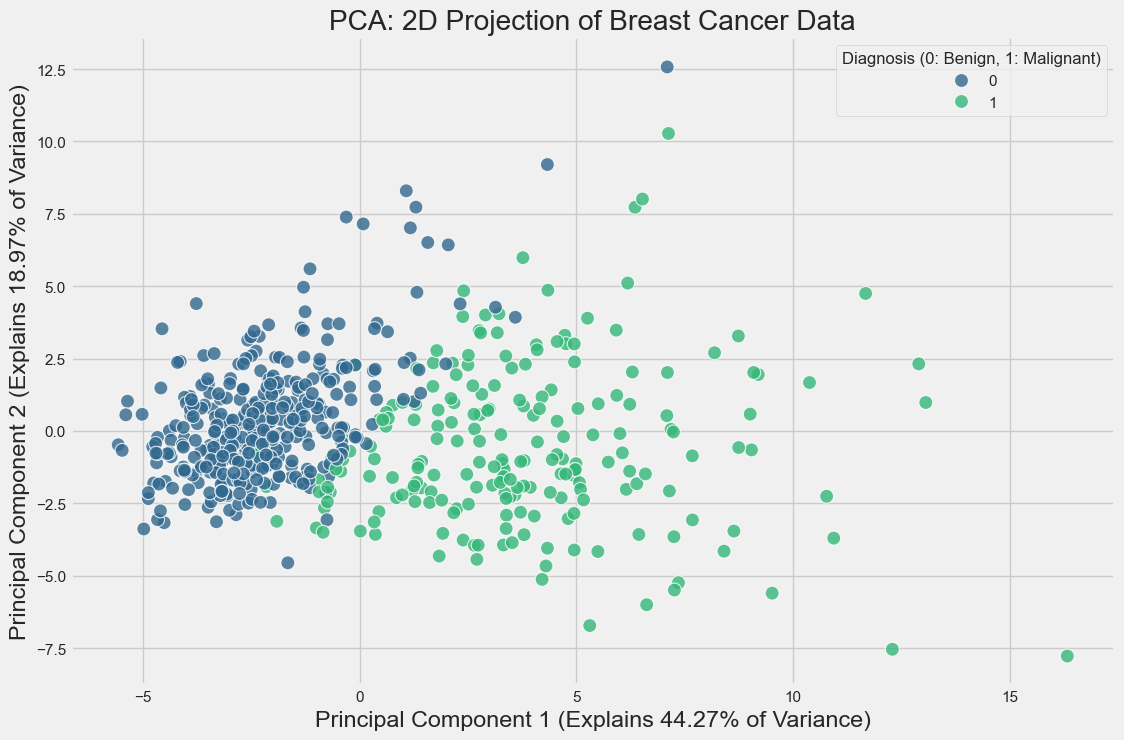

In [98]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Prepare the data
# Separate features (X) and target (y)
X = data.drop(['diagnosis'], axis=1)
y = data['diagnosis']

# 2. Standardize the data (Crucial for PCA as it is scale-sensitive)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Create a DataFrame for visualization
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['diagnosis'] = y

# 5. Visualize the 2D Projection
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='diagnosis', data=pca_df, palette='viridis', s=100, alpha=0.8)

# Add informative title and labels
plt.title('PCA: 2D Projection of Breast Cancer Data')
plt.xlabel(f'Principal Component 1 (Explains {pca.explained_variance_ratio_[0]:.2%} of Variance)')
plt.ylabel(f'Principal Component 2 (Explains {pca.explained_variance_ratio_[1]:.2%} of Variance)')
plt.legend(title='Diagnosis (0: Benign, 1: Malignant)', loc='best')
plt.grid(True)
plt.show()

# 📝 Conclusion and Insights

The following critical findings were obtained from the Exploratory Data Analysis (EDA):

### 1. Data Quality
* There are no missing values in the dataset.
* The dataset has been cleaned (unnecessary columns removed) and is ready for modeling.

### 2. Feature Separability
* As observed in the **Histograms and Boxplots**, features such as `radius_mean`, `perimeter_mean`, `area_mean`, and `concave points_mean` are highly effective in distinguishing between benign and malignant tumors.
* General Rule: **As feature values increase (larger, rougher, more irregular nuclei), the risk of malignancy increases.**

### 3. Correlation Status
* The Correlation Heatmap reveals that geometric features like "Radius, Perimeter, and Area" are **highly correlated (approx. 99%).**
* This suggests that for future modeling (especially resource-constrained models like QSVM), **Feature Selection** could be applied to remove redundant features without losing significant information.

### 4. PCA and Separability
* When the 30-dimensional data was reduced to 2 dimensions using PCA, the Malignant (M) and Benign (B) classes were observed to be **almost linearly separable.**
* This result serves as strong evidence that algorithms like **SVM (Support Vector Machines)** are likely to achieve high accuracy (Accuracy > 95%) on this dataset.